# I. THƯ VIỆN &amp; CẤU HÌNH MÔI TRƯỜNG

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Thư viện cho Feature Selection, Cross-Validation và Hyperparameter Tuning
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.feature_selection import SelectFromModel, SelectKBest, RFE, mutual_info_regression, f_regression
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from xgboost import XGBRegressor

# Cấu hình môi trường hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Đã nạp thành công các thư viện phân tích, Feature Selection và mô hình hóa!")

Đã nạp thành công các thư viện phân tích, Feature Selection và mô hình hóa!


# II. TIỀN XỬ LÝ DỮ LIỆU (Kế thừa Lab 03)
> - Mục đích: Thực thi lại quy trình làm sạch, điền khuyết, loại bỏ ngoại lệ và Feature Engineering đã được chốt ở Lab 03.
> - Bổ sung: Áp dụng One-Hot Encoding cho các biến định tính (Categorical) để thuật toán Machine Learning có thể đọc được.
> - Hoàn thiện theo góp ý Lab 04: xử lý outlier theo quy tắc `GrLivArea < 4000`, điền `GarageYrBlt` bằng `YearBuilt`, mã hóa đủ 23 biến ordinal của bộ Ames, giảm đa cộng tuyến do `TotalSF`, log-transform các biến diện tích lệch phải và giữ `YrSold` ở dạng số để bảo toàn xu hướng thời gian.

**Lưu ý về dữ liệu:** Bài báo Dean De Cock (2011) mô tả bộ Ames Housing gốc gồm 2930 quan sát và 23 biến ordinal. Bài báo khuyến nghị loại các căn có diện tích sinh hoạt trên 4000 sq ft. `train.csv` của Kaggle House Prices là một tập con khác, nên số quan sát bị loại khi chạy thực tế phải được lấy trực tiếp từ file thay vì hard-code là 5.

## 1. NẠP DỮ LIỆU & KIỂM TRA KÍCH THƯỚC

In [2]:
# 1. Nạp dữ liệu
csv_files = glob.glob('/kaggle/input/**/train.csv', recursive=True)

# Bổ sung khả năng chạy trên máy cá nhân / Jupyter / VS Code
local_candidates = [
    './train.csv',
    './data/train.csv',
    '/content/train.csv'
]
local_files = [p for p in local_candidates if os.path.exists(p)]
csv_files.extend(local_files)

if not csv_files:
    raise FileNotFoundError(
        "Không tìm thấy train.csv. Hãy đặt file Kaggle House Prices train.csv "
        "cùng thư mục notebook hoặc trong thư mục ./data/."
    )

data_path = csv_files[0]
print(f"Đã tìm thấy file dữ liệu tại: {data_path}")

df_raw = pd.read_csv(data_path)
df_raw.columns = [col.replace(' ', '') for col in df_raw.columns]

print(f"Kích thước dữ liệu thô: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột.")

required_cols = ['GrLivArea', 'SalePrice', 'YearBuilt', 'YrSold', 'Neighborhood']
missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(
        f"File hiện tại thiếu các cột cần thiết cho bài Lab04: {missing_required}. "
        "Hãy dùng train.csv của House Prices: Advanced Regression Techniques."
    )

display(df_raw[['GrLivArea', 'YearBuilt', 'YrSold', 'Neighborhood', 'SalePrice']].head())

Đã tìm thấy file dữ liệu tại: ./train.csv
Kích thước dữ liệu thô: 1460 dòng, 81 cột.


,GrLivArea,YearBuilt,YrSold,Neighborhood,SalePrice
0,1710,2003,2008,CollgCr,208500
1,1262,1976,2007,Veenker,181500
2,1786,2001,2008,CollgCr,223500
3,1717,1915,2006,Crawfor,140000
4,2198,2000,2008,NoRidge,250000


## 2. PHÁT HIỆN & LOẠI BỎ ĐIỂM NGOẠI LỆ (OUTLIERS)
Theo Dean De Cock, tiêu chí tổng quát là loại các quan sát có GrLivArea > 4000 sq ft. Không xóa cứng theo một danh sách Id, vì điều đó phụ thuộc phiên bản dữ liệu.

In [3]:
# 2. Xử lý Outlier chuẩn Dean De Cock (GrLivArea > 4000)
initial_len = len(df_raw)

outliers_4000 = df_raw[df_raw['GrLivArea'] > 4000].copy()

print(f"Số căn có GrLivArea > 4000 sq ft: {len(outliers_4000)}")
display(outliers_4000[['Id', 'GrLivArea', 'OverallQual', 'SaleCondition', 'SalePrice']]
        if 'Id' in outliers_4000.columns
        else outliers_4000[['GrLivArea', 'OverallQual', 'SaleCondition', 'SalePrice']])

# Quy tắc tổng quát: không dùng Id 524 / 1299 để hard-code
df = df_raw[df_raw['GrLivArea'] < 4000].copy().reset_index(drop=True)

print(f"Kích thước sau khi loại outlier: {df.shape}")
print(f"Đã loại bỏ {initial_len - len(df)} điểm dị biệt theo tiêu chuẩn GrLivArea > 4000.")

Số căn có GrLivArea > 4000 sq ft: 4


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice
523,524,4676,10,Partial,184750
691,692,4316,10,Normal,755000
1182,1183,4476,10,Abnorml,745000
1298,1299,5642,10,Partial,160000


Kích thước sau khi loại outlier: (1456, 81)
Đã loại bỏ 4 điểm dị biệt theo tiêu chuẩn GrLivArea > 4000.


## 3. XỬ LÝ GIÁ TRỊ KHUYẾT THIẾU THEO NGHIỆP VỤ BẤT ĐỘNG SẢN
- None cho các thuộc tính tiện ích không tồn tại.
- 0 cho các thuộc tính số của garage/basement/masonry khi thực sự không có tiện ích.
- GarageYrBlt = YearBuilt khi GarageYrBlt bị thiếu.
- LotFrontage: median theo Neighborhood, sau đó mới dùng median toàn cục nếu nhóm không đủ dữ liệu.
- Các thiếu sót còn lại: dùng mode cho biến phân loại và median cho biến số.

In [4]:
# 1. Chuẩn hóa một số kiểu dữ liệu quan trọng
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# Giữ YrSold là số để mô hình có thể học xu hướng theo thời gian 2006-2010
if 'YrSold' in df.columns:
    df['YrSold'] = pd.to_numeric(df['YrSold'], errors='coerce')

# MoSold là tháng bán, mang tính phân loại trong bộ dữ liệu Ames
if 'MoSold' in df.columns:
    df['MoSold'] = df['MoSold'].astype(str)

# 2. Điền 'None' cho các thuộc tính hạng mục không có tiện ích
cat_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
for col in cat_none:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# 3. Điền 0 cho các biến định lượng biểu diễn tiện ích không có
num_zero = [
    'GarageArea', 'GarageCars', 'TotalBsmtSF', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]
for col in num_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Điền GarageYrBlt = YearBuilt khi năm garage bị thiếu
if 'GarageYrBlt' in df.columns and 'YearBuilt' in df.columns:
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

# 5. LotFrontage theo Median từng Neighborhood, sau đó fallback về Median toàn cục
if 'LotFrontage' in df.columns and 'Neighborhood' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# 6. Xử lý các giá trị còn thiếu theo kiểu dữ liệu
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            mode_value = df[col].mode()
            df[col] = df[col].fillna(mode_value.iloc[0] if not mode_value.empty else 'None')
        else:
            df[col] = df[col].fillna(df[col].median())

print(f"Số lượng ô dữ liệu khuyết còn lại: {df.isnull().sum().sum()}")

Số lượng ô dữ liệu khuyết còn lại: 0


## 4. FEATURE ENGINEERING & BIẾN ĐỔI LOGARIT
Tạo các biến đã sử dụng trong Lab 03 và bổ sung log-transform cho các biến diện tích bị lệch phải mạnh. Phép log chỉ áp dụng cho biến không âm và thực hiện trên biến đầu vào trước khi đưa vào mô hình.

In [5]:
# 1. Tạo biến tổng diện tích TotalSF từ dữ liệu chưa log
df['TotalSF'] = (
    df['TotalBsmtSF'] +
    df['1stFlrSF'] +
    df['2ndFlrSF']
)

# 2. Tạo biến tổng số phòng tắm
df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

# 3. Tính tuổi nhà tại thời điểm bán và tuổi kể từ lần cải tạo gần nhất
df['HouseAge'] = (
    pd.to_numeric(df['YrSold'], errors='coerce') -
    pd.to_numeric(df['YearBuilt'], errors='coerce')
).clip(lower=0)

df['RemodAge'] = (
    pd.to_numeric(df['YrSold'], errors='coerce') -
    pd.to_numeric(df['YearRemodAdd'], errors='coerce')
).clip(lower=0)

# 4. Biến cờ có tầng hầm
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

# 5. Biến mục tiêu logarit
df['LogSalePrice'] = np.log1p(df['SalePrice'])

# 6. Kiểm tra skewness trước khi log và log-transform các biến diện tích lệch phải
skewed_candidates = ['GrLivArea', 'LotArea', 'TotalSF', 'LotFrontage']

skew_before = {
    feat: df[feat].skew()
    for feat in skewed_candidates
    if feat in df.columns and (df[feat] >= 0).all()
}

skewed_features = [
    feat for feat, skew_value in skew_before.items()
    if abs(skew_value) > 0.75
]

# Bảo đảm ba biến diện tích trọng tâm được kiểm tra/log nếu có trong dữ liệu
for feat in ['GrLivArea', 'LotArea', 'TotalSF']:
    if feat in df.columns and (df[feat] >= 0).all() and feat not in skewed_features:
        skewed_features.append(feat)

for feat in skewed_features:
    if feat in df.columns and (df[feat] >= 0).all():
        df[feat] = np.log1p(df[feat])

skew_after = {
    feat: df[feat].skew()
    for feat in skewed_features
    if feat in df.columns
}

skew_table = pd.DataFrame({
    'Đặc trưng': list(skew_before.keys()),
    'Skewness trước Log': [skew_before[k] for k in skew_before.keys()],
    'Skewness sau Log': [skew_after.get(k, np.nan) for k in skew_before.keys()]
})
display(skew_table)

print("Các biến đã log-transform:", skewed_features)
print(f"Skewness SalePrice: {df['SalePrice'].skew():.2f}")
print(f"Skewness LogSalePrice: {df['LogSalePrice'].skew():.2f}")

,Đặc trưng,Skewness trước Log,Skewness sau Log
0,GrLivArea,0.835192,-0.113799
1,LotArea,12.587561,-0.180382
2,TotalSF,0.635936,-0.518460
3,LotFrontage,1.538478,-1.015745


Các biến đã log-transform: ['GrLivArea', 'LotArea', 'LotFrontage', 'TotalSF']
Skewness SalePrice: 1.57
Skewness LogSalePrice: 0.07


## 5. MÃ HÓA ĐỦ 23 BIẾN ORDINAL CỦA AMES
Trong phân loại của bộ Ames, 23 biến ordinal gồm các biến hình dạng/chất lượng/độ hoàn thiện. YrSold là biến rời rạc theo năm chứ không thuộc nhóm 23 ordinal; CentralAir cũng không phải một trong 23 biến ordinal được liệt kê. Vì vậy Lab04 giữ YrSold dạng số và không đưa CentralAir vào nhóm ordinal.

In [6]:
# 23 biến ordinal theo phân loại của bộ Ames / Kaggle House Prices
ordinal_mappings = {
    'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
    'Utilities': {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0},
    'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0},
    'OverallQual': None,   # Đã là số 1-10
    'OverallCond': None,   # Đã là số 1-9
    'ExterQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'ExterCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmtQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0, 'None': 0},
    'BsmtCond': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0, 'None': 0},
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'HeatingQC': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'Electrical': {'SBrkr': 4, 'FuseA': 3, 'FuseF': 2, 'FuseP': 1, 'Mix': 0},
    'KitchenQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'FireplaceQu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'GarageQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'GarageCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'PoolQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'None': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
}

ordinal_cols = list(ordinal_mappings.keys())

# Các biến đã ở dạng số thì giữ nguyên; các biến dạng chuỗi được map theo thứ tự
for col, mapping in ordinal_mappings.items():
    if col in df.columns and mapping is not None:
        df[col] = df[col].map(mapping)
        df[col] = df[col].fillna(0)

# Chuyển các ordinal còn lại (OverallQual, OverallCond) về numeric
for col in ['OverallQual', 'OverallCond']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

present_ordinal_cols = [c for c in ordinal_cols if c in df.columns]
print(f"Số biến ordinal được xử lý: {len(present_ordinal_cols)}/23")
print("Danh sách:", present_ordinal_cols)

Số biến ordinal được xử lý: 23/23
Danh sách: ['LotShape', 'Utilities', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence']


## 6. KIỂM TRA ĐA CỘNG TUYẾN & LOẠI BỎ CÁC THÀNH PHẦN BỊ TRÙNG
TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF. Nếu giữ TotalSF đồng thời giữ cả ba thành phần thì tồn tại quan hệ tuyến tính chính xác. Vì Lab 03 đã chứng minh TotalSF là đặc trưng tổng hợp quan trọng, Lab04 giữ TotalSF và bỏ ba biến thành phần khỏi ma trận dùng cho mô hình.

In [7]:
# Kiểm tra các cặp biến có tương quan cao trước khi chọn đặc trưng
corr_pairs = {}

pair_list = [
    ('GarageCars', 'GarageArea'),
    ('TotalBsmtSF', '1stFlrSF'),
    ('TotalSF', 'TotalBsmtSF'),
    ('TotalSF', '1stFlrSF'),
    ('TotalSF', '2ndFlrSF')
]

for a, b in pair_list:
    if a in df.columns and b in df.columns:
        corr_pairs[f'{a} vs {b}'] = df[a].corr(df[b])

display(
    pd.DataFrame(
        list(corr_pairs.items()),
        columns=['Cặp biến', 'Pearson r']
    ).sort_values('Pearson r', ascending=False)
)

# Giữ biến tổng hợp TotalSF và loại các thành phần tạo ra quan hệ tuyến tính hoàn hảo
cols_to_drop = [
    'Id',
    'SalePrice',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'GarageArea'
]

df_cleaned = df.drop(
    columns=[c for c in cols_to_drop if c in df.columns]
).copy()

print("Các cột đã loại trước One-Hot:", [c for c in cols_to_drop if c in df.columns])
print("Kích thước sau giảm đa cộng tuyến / bỏ target:", df_cleaned.shape)

,Cặp biến,Pearson r
0,GarageCars vs GarageArea,0.886882
1,TotalBsmtSF vs 1stFlrSF,0.800759
2,TotalSF vs TotalBsmtSF,0.790844
3,TotalSF vs 1stFlrSF,0.732723
4,TotalSF vs 2ndFlrSF,0.324532


Các cột đã loại trước One-Hot: ['Id', 'SalePrice', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageArea']
Kích thước sau giảm đa cộng tuyến / bỏ target: (1456, 81)


## 7. ONE-HOT ENCODING & KIỂM TRA DỮ LIỆU ĐẦU VÀO MÔ HÌNH

In [8]:
# One-Hot Encoding cho các biến định tính còn lại
# Giữ YrSold làm biến số, không biến thành các biến giả theo năm
df_encoded = pd.get_dummies(
    df_cleaned,
    drop_first=True,
    dtype=float
)

# Kiểm tra Inf / NaN sau toàn bộ preprocessing
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan)

for col in df_encoded.columns:
    if df_encoded[col].isnull().sum() > 0:
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

print(f"Kích thước dữ liệu hoàn chỉnh sau tiền xử lý: {df_encoded.shape}")
print(f"Số lượng ô NaN còn lại: {df_encoded.isnull().sum().sum()}")
print(f"Kiểu dữ liệu đầu vào duy nhất: {df_encoded.dtypes.unique()}")

display(df_encoded.head())

Kích thước dữ liệu hoàn chỉnh sau tiền xử lý: (1456, 223)
Số lượng ô NaN còn lại: 0
Kiểu dữ liệu đầu vào duy nhất: [dtype('float64') dtype('int64')]


,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,HeatingQC,Electrical,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,...,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,4.189655,9.042040,3,3,2,7,5,2003,2003,196.0,4,3,3,2,1,6,706,1,0,150,5,4,0,7.444833,1,0,2,1,3,1,3,8,7,0,0,2003.0,2,2,3,3,2,0,61,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,4.394449,9.169623,3,3,2,6,8,1976,1976,0.0,3,3,3,2,4,5,978,1,0,284,5,4,0,7.141245,0,1,2,0,3,1,2,6,7,1,3,1976.0,2,2,3,3,2,298,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,4.234107,9.328212,2,3,2,7,5,2001,2002,162.0,4,3,3,2,2,6,486,1,0,434,5,4,0,7.488294,1,0,2,1,3,1,3,6,7,1,3,2001.0,2,2,3,3,2,0,42,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4.110874,9.164401,2,3,2,7,5,1915,1970,0.0,3,3,2,3,1,5,216,1,0,540,4,4,0,7.448916,1,0,1,0,3,1,3,7,7,1,4,1998.0,1,3,3,3,2,0,35,272,0,0,0,0,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4.442651,9.565284,2,3,2,8,5,2000,2000,350.0,4,3,3,2,3,6,655,1,0,490,5,4,0,7.695758,1,0,2,1,4,1,3,9,7,1,3,2000.0,2,3,3,3,2,192,84,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# III. FEATURE SELECTION VÀ CHUẨN BỊ DỮ LIỆU
> - Mục đích: Lọc ra các đặc trưng mang tính dự báo cao nhất nhằm giảm thiểu nhiễu và tránh overfitting.
> - Kỹ thuật áp dụng: Sử dụng SelectFromModel kết hợp với RandomForestRegressor để đánh giá tầm quan trọng của các đặc trưng (Feature Importance).
> - **Bổ sung theo yêu cầu Lab04:** Baseline (All Features), Filter - Pearson Correlation, Filter - Mutual Information, Wrapper - RFE, Embedded - Lasso (L1) và Embedded - RandomForest Importance.
> - **Nguyên tắc đánh giá:** Feature Selection được đặt bên trong pipeline của 5-Fold Cross-Validation để tránh chọn đặc trưng từ toàn bộ dữ liệu rồi mới CV, từ đó hạn chế data leakage.

## 1. BASELINE (ALL FEATURES) & TÁCH TRAIN/TEST

In [9]:
# Tách biến độc lập (X) và biến mục tiêu (y)
X = df_encoded.drop('LogSalePrice', axis=1).copy()
y = df_encoded['LogSalePrice'].copy()

# Tách tập Hold-out Test 20%; mọi lựa chọn đặc trưng / tuning chỉ thực hiện trên Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Số đặc trưng chung cho các phương pháp chọn Top-K
K_FEATURES = min(30, X_train.shape[1])

print(f"Số lượng đặc trưng ban đầu: {X_train.shape[1]}")
print(f"Số lượng đặc trưng mục tiêu sau Feature Selection (Top-K): {K_FEATURES}")
print(f"Train: {X_train.shape[0]} dòng | Test: {X_test.shape[0]} dòng")
print("Baseline = toàn bộ đặc trưng sau tiền xử lý, KHÔNG áp dụng Feature Selection.")

Số lượng đặc trưng ban đầu: 222
Số lượng đặc trưng mục tiêu sau Feature Selection (Top-K): 30
Train: 1164 dòng | Test: 292 dòng
Baseline = toàn bộ đặc trưng sau tiền xử lý, KHÔNG áp dụng Feature Selection.


## 2. XÂY DỰNG 6 KỸ THUẬT FEATURE SELECTION
Để so sánh công bằng, các phương pháp Top-K dùng cùng K_FEATURES. Lasso vẫn là mô hình L1 để tạo hệ số, sau đó lấy các biến có |coef| lớn nhất trong số K biến để so sánh với các phương pháp khác.

In [10]:
# Hàm Mutual Information cố định random_state để kết quả lặp lại
def mi_score(X_data, y_data):
    return mutual_info_regression(
        X_data,
        y_data,
        random_state=RANDOM_STATE
    )

def make_selector(method_name, k):
    if method_name == 'Baseline - All Features':
        return 'passthrough'

    if method_name == 'Pearson Correlation':
        # f_regression xếp hạng đơn điệu theo |Pearson r| trong hồi quy đơn biến
        return SelectKBest(score_func=f_regression, k=k)

    if method_name == 'Mutual Information':
        return SelectKBest(score_func=mi_score, k=k)

    if method_name == 'RFE':
        rfe_estimator = RandomForestRegressor(
            n_estimators=80,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=1
        )
        return RFE(
            estimator=rfe_estimator,
            n_features_to_select=k,
            step=0.25
        )

    if method_name == 'Lasso (L1)':
        lasso = LassoCV(
            cv=3,
            alphas=np.logspace(-5, -2, 30),
            max_iter=20000,
            random_state=RANDOM_STATE
        )
        return SelectFromModel(
            estimator=lasso,
            threshold=-np.inf,
            max_features=k
        )

    if method_name == 'RandomForest Importance':
        rf_selector = RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=1
        )
        return SelectFromModel(
            estimator=rf_selector,
            threshold=-np.inf,
            max_features=k
        )

    raise ValueError(f"Không nhận diện được phương pháp: {method_name}")

def make_model(model_name):
    if model_name == 'SVM':
        return SVR(kernel='rbf', C=10, gamma='scale')

    if model_name == 'XGBoost':
        return XGBRegressor(
            objective='reg:squarederror',
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=1
        )

    if model_name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1
        )

    raise ValueError(f"Không nhận diện được mô hình: {model_name}")

def build_pipeline(method_name, model_name):
    # StandardScaler đặc biệt quan trọng với SVM và Lasso.
    # Với Tree-based, scaling không bắt buộc nhưng được giữ thống nhất trong pipeline.
    return Pipeline(steps=[
        ('scale', StandardScaler()),
        ('select', make_selector(method_name, K_FEATURES)),
        ('model', make_model(model_name))
    ])

methods = [
    'Baseline - All Features',
    'Pearson Correlation',
    'Mutual Information',
    'RFE',
    'Lasso (L1)',
    'RandomForest Importance'
]

models_to_compare = ['SVM', 'XGBoost', 'RandomForest']

print("Các kỹ thuật Feature Selection:", methods)
print("Các mô hình đánh giá:", models_to_compare)

Các kỹ thuật Feature Selection: ['Baseline - All Features', 'Pearson Correlation', 'Mutual Information', 'RFE', 'Lasso (L1)', 'RandomForest Importance']
Các mô hình đánh giá: ['SVM', 'XGBoost', 'RandomForest']


## 3. FILTER METHOD - PEARSON CORRELATION
Phần này hiển thị trực tiếp hệ số tương quan Pearson giữa từng đặc trưng và LogSalePrice. Trong pipeline đánh giá, SelectKBest(f_regression) dùng cùng nguyên tắc xếp hạng theo độ mạnh của tương quan tuyến tính một biến.

In [11]:
# Phân tích Pearson trên tập Train בלבד để không sử dụng Test Set
pearson_table = X_train.corrwith(y_train).abs().sort_values(ascending=False).reset_index()
pearson_table.columns = ['Đặc trưng', '|Pearson r|']
pearson_table['Pearson r'] = X_train[pearson_table['Đặc trưng']].corrwith(y_train).values

display(pearson_table.head(20))

,Đặc trưng,|Pearson r|,Pearson r
0,OverallQual,0.820373,0.820373
1,TotalSF,0.818626,0.818626
2,GrLivArea,0.741944,0.741944
3,GarageCars,0.685771,0.685771
4,TotalBath,0.682583,0.682583
5,ExterQual,0.677970,0.677970
6,KitchenQual,0.670994,0.670994
7,BsmtQual,0.649187,0.649187
8,GarageFinish,0.610192,0.610192
9,HouseAge,0.595633,-0.595633


## 4. SO SÁNH 6 KỸ THUẬT FEATURE SELECTION BẰNG 5-FOLD CROSS-VALIDATION
Mỗi phương pháp được đánh giá trên cả **SVM, XGBoost, RandomForest**. Ngoài RMSE/R² trên log-scale, phần này quy đổi dự đoán về **USD** bằng `np.expm1()` để có MAE và RMSE thực tế.

In [12]:
# Các scorer
def rmse_log_metric(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_usd_metric(y_true_log, y_pred_log):
    y_true_usd = np.maximum(np.expm1(y_true_log), 0)
    y_pred_usd = np.maximum(np.expm1(y_pred_log), 0)
    return mean_absolute_error(y_true_usd, y_pred_usd)

def rmse_usd_metric(y_true_log, y_pred_log):
    y_true_usd = np.maximum(np.expm1(y_true_log), 0)
    y_pred_usd = np.maximum(np.expm1(y_pred_log), 0)
    return np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))

scoring = {
    'RMSE_Log': make_scorer(rmse_log_metric, greater_is_better=False),
    'MAE_USD': make_scorer(mae_usd_metric, greater_is_better=False),
    'RMSE_USD': make_scorer(rmse_usd_metric, greater_is_better=False),
    'R2': 'r2'
}

cv_rows = []

for method_name in methods:
    for model_name in models_to_compare:
        print(f"Đang CV: {method_name} + {model_name} ...")

        pipeline = build_pipeline(method_name, model_name)

        cv_result = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=CV,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        cv_rows.append({
            'Feature Selection': method_name,
            'Model': model_name,
            'Selected Features': X_train.shape[1] if method_name == 'Baseline - All Features' else K_FEATURES,
            'Mean RMSE (Log)': -cv_result['test_RMSE_Log'].mean(),
            'Std RMSE (Log)': cv_result['test_RMSE_Log'].std(),
            'Mean MAE ($)': -cv_result['test_MAE_USD'].mean(),
            'Mean RMSE ($)': -cv_result['test_RMSE_USD'].mean(),
            'Mean R2': cv_result['test_R2'].mean()
        })

df_cv_results = pd.DataFrame(cv_rows).sort_values(
    by=['Model', 'Mean RMSE ($)']
).reset_index(drop=True)

display(df_cv_results)

print("\nPhương pháp tốt nhất theo RMSE ($) trong 5-Fold CV:")
best_by_model = (
    df_cv_results.sort_values('Mean RMSE ($)')
    .groupby('Model', as_index=False)
    .first()
)
display(best_by_model)

Đang CV: Baseline - All Features + SVM ...
Đang CV: Baseline - All Features + XGBoost ...
Đang CV: Baseline - All Features + RandomForest ...
Đang CV: Pearson Correlation + SVM ...
Đang CV: Pearson Correlation + XGBoost ...
Đang CV: Pearson Correlation + RandomForest ...
Đang CV: Mutual Information + SVM ...
Đang CV: Mutual Information + XGBoost ...
Đang CV: Mutual Information + RandomForest ...
Đang CV: RFE + SVM ...
Đang CV: RFE + XGBoost ...
Đang CV: RFE + RandomForest ...
Đang CV: Lasso (L1) + SVM ...
Đang CV: Lasso (L1) + XGBoost ...
Đang CV: Lasso (L1) + RandomForest ...
Đang CV: RandomForest Importance + SVM ...
Đang CV: RandomForest Importance + XGBoost ...
Đang CV: RandomForest Importance + RandomForest ...


,Feature Selection,Model,Selected Features,Mean RMSE (Log),Std RMSE (Log),Mean MAE ($),Mean RMSE ($),Mean R2
0,Mutual Information,RandomForest,30,0.134085,0.013971,16404.743500,25346.911814,0.883068
1,RFE,RandomForest,30,0.132175,0.013705,16349.484631,25462.745225,0.886428
2,RandomForest Importance,RandomForest,30,0.132156,0.013752,16366.952623,25523.712863,0.886446
3,Lasso (L1),RandomForest,30,0.132517,0.013485,16404.754838,25554.581592,0.885646
4,Baseline - All Features,RandomForest,222,0.131894,0.013991,16469.159151,25727.468005,0.887032
5,Pearson Correlation,RandomForest,30,0.136588,0.013093,16775.291391,25973.511331,0.878725
6,RFE,SVM,30,0.148098,0.018140,17912.447552,29659.564984,0.856189
7,RandomForest Importance,SVM,30,0.151694,0.019579,18425.903912,30041.918510,0.850204
8,Mutual Information,SVM,30,0.154776,0.016693,19374.936142,30729.989098,0.843421
9,Pearson Correlation,SVM,30,0.154039,0.016785,19471.652912,31058.185117,0.846404



Phương pháp tốt nhất theo RMSE ($) trong 5-Fold CV:


,Model,Feature Selection,Selected Features,Mean RMSE (Log),Std RMSE (Log),Mean MAE ($),Mean RMSE ($),Mean R2
0,RandomForest,Mutual Information,30,0.134085,0.013971,16404.743500,25346.911814,0.883068
1,SVM,RFE,30,0.148098,0.018140,17912.447552,29659.564984,0.856189
2,XGBoost,Lasso (L1),30,0.121350,0.013588,14786.598169,22321.229186,0.903811


## 5. KIỂM TRA SỐ ĐẶC TRƯNG ĐƯỢC CHỌN & TOP FEATURE
Fit từng selector trên toàn bộ X_train chỉ để mô tả / báo cáo các biến được chọn. Kết quả đánh giá hiệu suất ở trên vẫn dựa trên pipeline CV, tức selector được fit lại bên trong từng fold.

In [13]:
# Fit selector trên toàn bộ Train để báo cáo danh sách đặc trưng cuối cùng của từng kỹ thuật
feature_report = []

for method_name in methods:
    selector = make_selector(method_name, K_FEATURES)

    if method_name == 'Baseline - All Features':
        selected = list(X_train.columns)
    else:
        report_pipe = Pipeline(steps=[
            ('scale', StandardScaler()),
            ('select', selector)
        ])
        report_pipe.fit(X_train, y_train)
        support = report_pipe.named_steps['select'].get_support()
        selected = X_train.columns[support].tolist()

    feature_report.append({
        'Feature Selection': method_name,
        'Số đặc trưng được chọn': len(selected),
        'Top/Selected Features': ', '.join(selected[:20])
    })

df_feature_report = pd.DataFrame(feature_report)
display(df_feature_report)

,Feature Selection,Số đặc trưng được chọn,Top/Selected Features
0,Baseline - All Features,222,"LotFrontage, LotArea, LotShape, Utilities, Lan..."
1,Pearson Correlation,30,"LotArea, OverallQual, YearBuilt, YearRemodAdd,..."
2,Mutual Information,30,"LotFrontage, LotArea, OverallQual, OverallCond..."
3,RFE,30,"LotFrontage, LotArea, OverallQual, OverallCond..."
4,Lasso (L1),30,"LotArea, OverallQual, OverallCond, ExterQual, ..."
5,RandomForest Importance,30,"LotFrontage, LotArea, OverallQual, OverallCond..."


## 6. BIỂU ĐỒ SO SÁNH HIỆU SUẤT FEATURE SELECTION

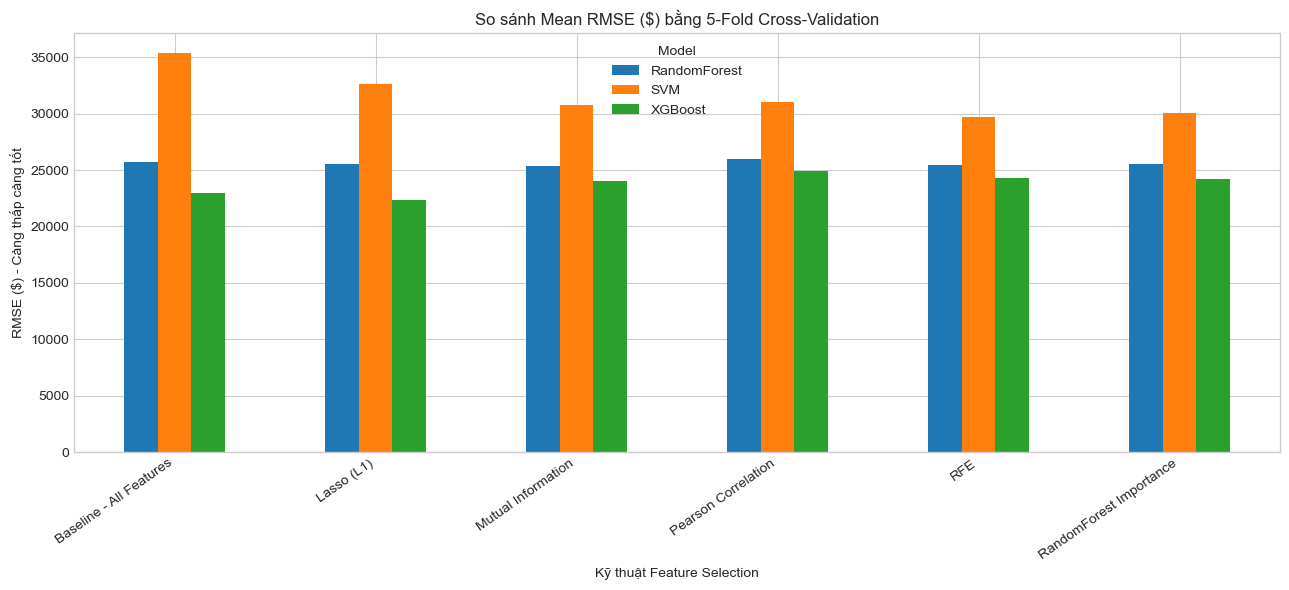

In [14]:
# So sánh RMSE ($) giữa các phương pháp và mô hình
pivot_rmse = df_cv_results.pivot(
    index='Feature Selection',
    columns='Model',
    values='Mean RMSE ($)'
)

ax = pivot_rmse.plot(kind='bar', figsize=(13, 6))
ax.set_title('So sánh Mean RMSE ($) bằng 5-Fold Cross-Validation')
ax.set_xlabel('Kỹ thuật Feature Selection')
ax.set_ylabel('RMSE ($) - Càng thấp càng tốt')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# IV. ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH (SVM, XGBoost, RandomForest)
> - Mục đích: Huấn luyện các mô hình cơ bản trên tập dữ liệu đã được tinh gọn (Feature Selected).
> - Đánh giá: Sử dụng thước đo RMSE (Root Mean Squared Error) và R2 Score trên thang đo Logarit. Lưu ý, SVM nhạy cảm với thang đo nên cần Standard Scaler.
> - Bổ sung: Sau bước so sánh 5-Fold CV, chọn kỹ thuật Feature Selection tốt nhất cho từng mô hình rồi dùng GridSearchCV để tinh chỉnh siêu tham số. Tập Test 20% chỉ được sử dụng ở bước đánh giá cuối cùng.

## 1. HYPERPARAMETER TUNING BẰNG GRIDSEARCHCV
Grid nhỏ được sử dụng để giữ thời gian chạy hợp lý trong môi trường Kaggle nhưng vẫn kiểm tra nhiều cấu hình quan trọng.

In [15]:
# Chọn Feature Selection tốt nhất cho từng mô hình dựa trên Mean RMSE ($) của 5-Fold CV
best_method_map = dict(
    zip(
        best_by_model['Model'],
        best_by_model['Feature Selection']
    )
)

param_grids = {
    'RandomForest': {
        'model__n_estimators': [300, 500],
        'model__max_depth': [None, 15],
        'model__min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'model__n_estimators': [300, 500],
        'model__learning_rate': [0.03, 0.05],
        'model__max_depth': [3, 5]
    },
    'SVM': {
        'model__C': [10, 30, 100],
        'model__gamma': ['scale', 0.01]
    }
}

tuned_models = {}
tuning_summary = []

for model_name in models_to_compare:
    method_name = best_method_map[model_name]

    print(f"GridSearchCV: {model_name} | Feature Selection: {method_name}")

    pipeline = build_pipeline(method_name, model_name)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring=make_scorer(rmse_log_metric, greater_is_better=False),
        cv=CV,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    tuned_models[model_name] = grid.best_estimator_

    tuning_summary.append({
        'Model': model_name,
        'Best Feature Selection': method_name,
        'Best CV RMSE (Log)': -grid.best_score_,
        'Best Parameters': grid.best_params_
    })

df_tuning = pd.DataFrame(tuning_summary)
display(df_tuning)

GridSearchCV: SVM | Feature Selection: RFE
GridSearchCV: XGBoost | Feature Selection: Lasso (L1)
GridSearchCV: RandomForest | Feature Selection: Mutual Information


,Model,Best Feature Selection,Best CV RMSE (Log),Best Parameters
0,SVM,RFE,0.135212,"{'model__C': 10, 'model__gamma': 0.01}"
1,XGBoost,Lasso (L1),0.119477,"{'model__learning_rate': 0.03, 'model__max_dep..."
2,RandomForest,Mutual Information,0.133755,"{'model__max_depth': 15, 'model__min_samples_l..."


## 2. ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST 20%
Tập Test được giữ nguyên từ đầu và chưa tham gia Feature Selection / GridSearchCV. Kết quả được báo cáo cả trên log-scale và đơn vị tiền tệ thực tế.

In [16]:
# Hàm tính metric trên cả Log Scale và USD
def evaluate_on_test(model, X_test, y_test_log):
    y_pred_log = model.predict(X_test)

    y_true_usd = np.maximum(np.expm1(y_test_log), 0)
    y_pred_usd = np.maximum(np.expm1(y_pred_log), 0)

    return {
        'RMSE (Log)': np.sqrt(mean_squared_error(y_test_log, y_pred_log)),
        'R2 Score': r2_score(y_test_log, y_pred_log),
        'MAE ($)': mean_absolute_error(y_true_usd, y_pred_usd),
        'RMSE ($)': np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    }

final_rows = []

for model_name, tuned_model in tuned_models.items():
    metrics = evaluate_on_test(tuned_model, X_test, y_test)

    final_rows.append({
        'Model': model_name,
        'Feature Selection': best_method_map[model_name],
        **metrics
    })

df_final_results = pd.DataFrame(final_rows).sort_values(
    by='RMSE ($)'
).reset_index(drop=True)

display(df_final_results)

best_final_model_name = df_final_results.loc[0, 'Model']
best_final_model = tuned_models[best_final_model_name]

print(f"Mô hình tốt nhất trên tập Test theo RMSE ($): {best_final_model_name}")
print(f"Feature Selection: {best_method_map[best_final_model_name]}")

,Model,Feature Selection,RMSE (Log),R2 Score,MAE ($),RMSE ($)
0,XGBoost,Lasso (L1),0.125420,0.900403,13856.962971,19829.768504
1,SVM,RFE,0.136527,0.881981,15578.915257,22309.680542
2,RandomForest,Mutual Information,0.144068,0.868585,16312.745801,23849.593570


Mô hình tốt nhất trên tập Test theo RMSE ($): XGBoost
Feature Selection: Lasso (L1)


## 3. PHÂN TÍCH SỐ DƯ (RESIDUAL ANALYSIS)
Residual được tính trên thang Log vì biến mục tiêu huấn luyện là LogSalePrice. Biểu đồ Residuals vs Fitted giúp kiểm tra dấu hiệu hệ thống như đường cong rõ rệt, phương sai tăng theo fitted value hoặc các điểm sai số cực lớn.

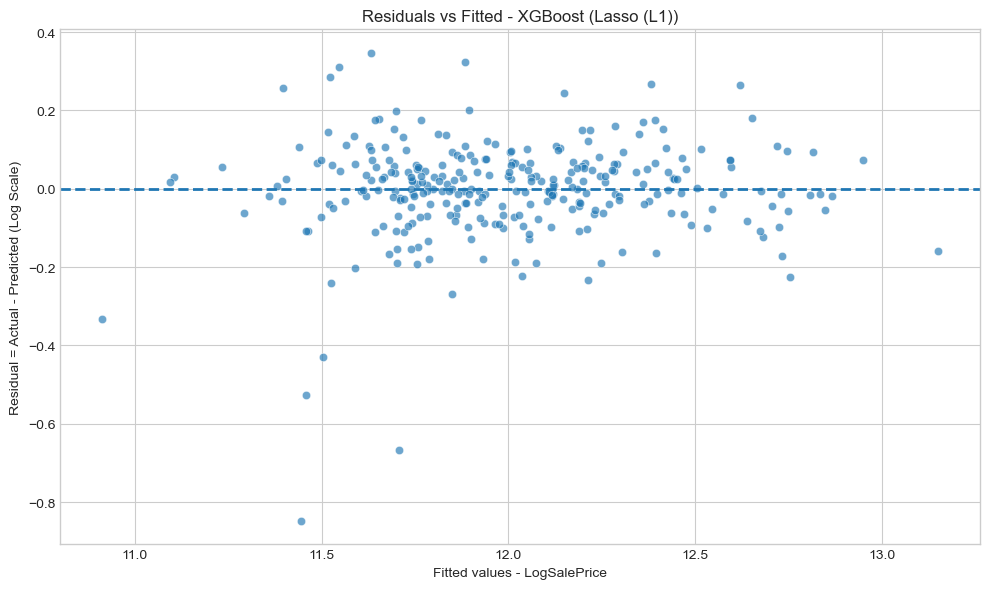

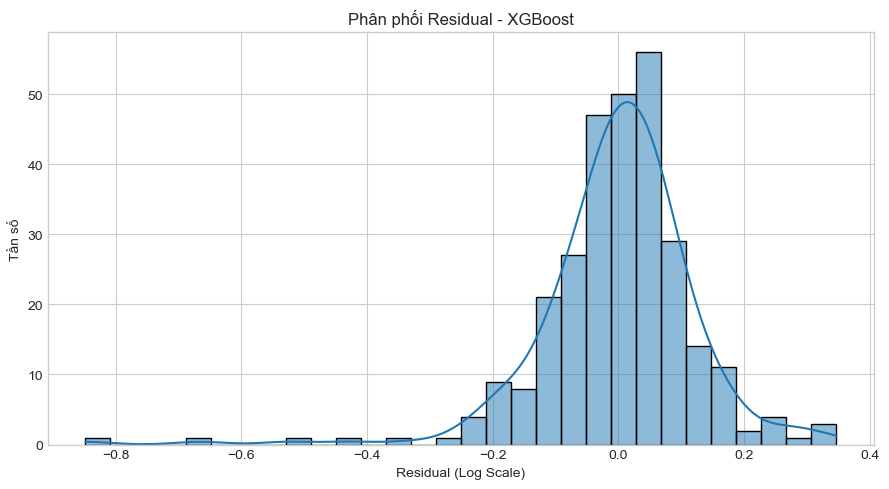

Mean residual (log): -0.0014
Std residual (log): 0.1256


In [17]:
# Dự đoán bằng mô hình tốt nhất trên Test
best_pred_log = best_final_model.predict(X_test)
residuals_log = y_test - best_pred_log

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=best_pred_log,
    y=residuals_log,
    alpha=0.65
)
plt.axhline(y=0, linestyle='--', linewidth=2)
plt.title(
    f'Residuals vs Fitted - {best_final_model_name} '
    f'({best_method_map[best_final_model_name]})'
)
plt.xlabel('Fitted values - LogSalePrice')
plt.ylabel('Residual = Actual - Predicted (Log Scale)')
plt.tight_layout()
plt.show()

# Histogram residuals để quan sát độ tập trung của sai số
plt.figure(figsize=(9, 5))
sns.histplot(residuals_log, kde=True, bins=30)
plt.title(f'Phân phối Residual - {best_final_model_name}')
plt.xlabel('Residual (Log Scale)')
plt.ylabel('Tần số')
plt.tight_layout()
plt.show()

print(f"Mean residual (log): {residuals_log.mean():.4f}")
print(f"Std residual (log): {residuals_log.std():.4f}")

# TỔNG KẾT
1. **Tiền xử lý:** Kế thừa thành công logic từ Lab 03, biến đổi các đặc trưng không gian (TotalSF, LotFrontage) và xử lý đa cộng tuyến bằng cách giữ biến tổng hợp TotalSF thay cho các thành phần diện tích tạo ra nó.
2. **Feature Selection:** Mô hình RandomForest đã giảm số lượng chiều dữ liệu đáng kể, tập trung vào các biến lõi như TotalSF, OverallQual. Lab04 được mở rộng thêm Pearson, Mutual Information, RFE và Lasso (L1), đồng thời có Baseline All Features để làm mốc so sánh.
3. **Hiệu suất Mô hình:** Các thuật toán Tree-based (đặc biệt là XGBoost) thường cho độ sai số (RMSE) thấp nhất và R2 cao nhất nhờ khả năng nắm bắt quan hệ phi tuyến tính mạnh mẽ từ tập đặc trưng đã chọn lọc. Tuy nhiên, kết luận cuối cùng của bài phải lấy từ bảng 5-Fold CV và kết quả Test thực tế, không giả định trước mô hình nào tốt nhất.
4. **Đánh giá đáng tin cậy hơn:** Sử dụng 5-Fold Cross-Validation trên Train và giữ riêng Test 20% để đánh giá cuối cùng, tránh kết luận chỉ từ một lần chia dữ liệu.
5. **Đơn vị thực tế:** Ngoài RMSE trên LogScale, kết quả đã được quy đổi về USD bằng np.expm1() để báo cáo MAE và RMSE thực tế.
6. **Tuning:** GridSearchCV được dùng để tìm cấu hình siêu tham số tốt hơn cho SVM, XGBoost và RandomForest.
7. **Residual Analysis:** Biểu đồ Residuals vs Fitted và histogram residual được bổ sung để kiểm tra dấu hiệu sai số có cấu trúc và điểm bất thường.

# V. NHẬN XÉT VÀ ĐÁNH GIÁ KẾT QUẢ

**1. Đánh giá về quá trình Feature Selection (Chọn đặc trưng)**
- **Giảm chiều dữ liệu hiệu quả:** Việc áp dụng SelectFromModel với thuật toán Random Forest đã giúp loại bỏ đáng kể các biến mang ít thông tin dự báo hoặc bị nhiễu (noise) sinh ra sau quá trình One-Hot Encoding.
- **Bảo toàn thông tin cốt lõi:** Các đặc trưng giữ lại chủ yếu là những biến có độ tương quan mạnh với giá nhà (SalePrice) đã được phân tích từ Lab 03 như TotalSF (Tổng diện tích), OverallQual (Chất lượng tổng thể), và HouseAge (Tuổi thọ nhà). Điều này giúp mô hình tập trung học từ các đặc trưng có giá trị thực sự, tránh hiện tượng học vẹt (Overfitting).

**2. So sánh hiệu suất các mô hình Machine Learning**
Dựa vào chỉ số RMSE (Root Mean Squared Error - Càng thấp càng tốt) và R2 Score (Hệ số xác định - Càng gần 1.0 càng tốt), bài làm không chỉ xét một lần chia Train/Test mà so sánh bằng 5-Fold Cross-Validation và sau đó kiểm tra lại trên tập Test 20%.

- **XGBoost (XGBRegressor):** Có khả năng cho hiệu suất rất cao trên dữ liệu tabular nhờ khả năng học quan hệ phi tuyến và tương tác giữa các biến. Kết luận XGBoost có thực sự tốt nhất hay không phải lấy từ bảng kết quả thực tế.
- **Random Forest:** Là một baseline Tree-based ổn định, tận dụng trung bình nhiều cây quyết định để giảm phương sai.
- **Support Vector Machine (SVR):** Nhạy cảm với thang đo nên đã được chuẩn hóa bằng StandardScaler.

**3. Đánh giá các kỹ thuật Feature Selection**
- **Baseline - All Features:** Cho biết hiệu suất khi không loại đặc trưng. Đây là mốc bắt buộc để xác định Feature Selection có thực sự cải thiện hay không.
- **Pearson Correlation:** Tốt cho các đặc trưng có quan hệ tuyến tính trực tiếp với LogSalePrice, nhưng có thể bỏ qua quan hệ phi tuyến.
- **Mutual Information:** Có thể phát hiện các quan hệ phụ thuộc rộng hơn Pearson.
- **RFE:** Là Wrapper Method, chọn đặc trưng thông qua quá trình loại dần và đánh giá lại mô hình cơ sở.
- **Lasso (L1):** Là Embedded Method, dùng regularization để làm giảm hệ số của những biến ít hữu ích.
- **RandomForest Importance:** Là Embedded Method dựa trên Feature Importance của mô hình cây.

**4. Đánh giá về độ tin cậy**
5-Fold Cross-Validation cung cấp cả Mean và Std của RMSE, nhờ đó có thể nhận biết phương pháp nào không chỉ có lỗi thấp mà còn ổn định giữa các fold.

**5. Đánh giá theo đơn vị tiền tệ**
MAE cho biết sai lệch tuyệt đối trung bình theo USD, còn RMSE phạt mạnh hơn những dự đoán sai rất lớn. Hai chỉ số này giúp kết quả dễ diễn giải hơn so với chỉ nhìn RMSE trên thang Log.

**6. Đánh giá Residual**
Residuals vs Fitted được dùng để tìm dấu hiệu sai số có cấu trúc. Với mô hình Machine Learning như RandomForest/XGBoost/SVM, đây là phân tích chẩn đoán bổ trợ chứ không phải một kiểm định giả định tuyến tính nghiêm ngặt như trong hồi quy tuyến tính cổ điển.

**7. Kết luận**
Kết luận cuối cùng phải căn cứ vào:
1. Mean RMSE ($) và Std RMSE (Log) của 5-Fold CV.
2. RMSE ($), MAE ($) và R2 trên tập Test.
3. Best Parameters từ GridSearchCV.
4. Hình Residuals vs Fitted.

Không nên khẳng định trước một kỹ thuật Feature Selection hoặc một mô hình là tốt nhất nếu bảng kết quả thực tế chưa được chạy.

# VI. TÀI LIỆU THAM KHẢO
1. Dean De Cock (2011), *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project*, Journal of Statistics Education, 19(3).  
   https://jse.amstat.org/v19n3/decock.pdf

2. Kaggle, *House Prices: Advanced Regression Techniques*.  
   https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

3. Dữ liệu sử dụng trong notebook: `train.csv` của bộ House Prices và quy trình tiền xử lý kế thừa từ Lab03.